In [178]:
import importlib
import solver
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

In [ ]:
# Initial Conditions: split into two regions by initial discontinuity
WL = {"rho":1.0,   "u":0.0, "p":100000.0}
WR = {"rho":0.125, "u":0.0, "p":10000.0}

# Boundary conditions: Fixed (Dirichlet) at both ends
XMIN = -10.0
XMAX = 10.0
N = 50
CFL = 0.4
GAMMA = 1.4 # air
T_END = 0.01


In [ ]:
# import reference solution
variables = ["density", "entropy", "mach", "massflux", "pressure", "velocity"]
dfs = []
folder = "exact/"
for i,var in enumerate(variables):
    file_name = f"{var}.exa"
    df = pd.read_csv(
        folder + file_name,
        sep=r"\s+",
        skiprows=1,
        names=["x", var],
        engine="python"
    )
    if i>0:
        df = df.drop(columns=["x"])
    dfs.append(df)
exact_df = pd.concat(dfs, axis=1)
exact_df["total_energy"] = (
    exact_df["pressure"] / ((GAMMA - 1)*exact_df["density"])
    + 0.5 *exact_df["velocity"]**2
)


,x,density,entropy,mach,massflux,pressure,velocity,total_energy,speed_of_sound
1554,5.54,0.265574,8735.950316,0.733678,77.889123,30313.017805,293.28627,328362.506921,399.747941
1555,5.55,0.125000,8697.218246,0.733678,0.000000,10000.000000,293.28627,200000.000000,399.747941
1556,5.56,0.125000,8697.218246,0.733678,0.000000,10000.000000,293.28627,200000.000000,399.747941
1557,5.57,0.125000,8697.218246,0.733678,0.000000,10000.000000,293.28627,200000.000000,399.747941
1558,5.58,0.125000,8697.218246,0.733678,0.000000,10000.000000,293.28627,200000.000000,399.747941
...,...,...,...,...,...,...,...,...,...
1996,9.96,0.125000,8697.218246,0.733678,0.000000,10000.000000,293.28627,200000.000000,399.747941
1997,9.97,0.125000,8697.218246,0.733678,0.000000,10000.000000,293.28627,200000.000000,399.747941
1998,9.98,0.125000,8697.218246,0.733678,0.000000,10000.000000,293.28627,200000.000000,399.747941
1999,9.99,0.125000,8697.218246,0.733678,0.000000,10000.000000,293.28627,200000.000000,399.747941


In [ ]:
importlib.reload(solver)
Physics, Solver = solver.Physics, solver.Solver

solver_sw = Solver(
    scheme="sw",
    xmin=XMIN,
    xmax=XMAX,
    N=N,
    wl=WL,
    wr=WR,
    CFL=CFL
)



solver_vl = Solver(
    scheme="vl",
    xmin=XMIN,
    xmax=XMAX,
    N=N,
    wl=WL,
    wr=WR,
    CFL=CFL
)


results_dict = {
    "sw": solver_sw.run(0.0, 0.01),
    "vl": solver_vl.run(0.0, 0.01)
}


[-10.   -9.6  -9.2  -8.8  -8.4  -8.   -7.6  -7.2  -6.8  -6.4  -6.   -5.6
  -5.2  -4.8  -4.4  -4.   -3.6  -3.2  -2.8  -2.4  -2.   -1.6  -1.2  -0.8
  -0.4   0.    0.4   0.8   1.2   1.6   2.    2.4   2.8   3.2   3.6   4.
   4.4   4.8   5.2   5.6   6.    6.4   6.8   7.2   7.6   8.    8.4   8.8
   9.2   9.6  10. ]
[-10.   -9.6  -9.2  -8.8  -8.4  -8.   -7.6  -7.2  -6.8  -6.4  -6.   -5.6
  -5.2  -4.8  -4.4  -4.   -3.6  -3.2  -2.8  -2.4  -2.   -1.6  -1.2  -0.8
  -0.4   0.    0.4   0.8   1.2   1.6   2.    2.4   2.8   3.2   3.6   4.
   4.4   4.8   5.2   5.6   6.    6.4   6.8   7.2   7.6   8.    8.4   8.8
   9.2   9.6  10. ]


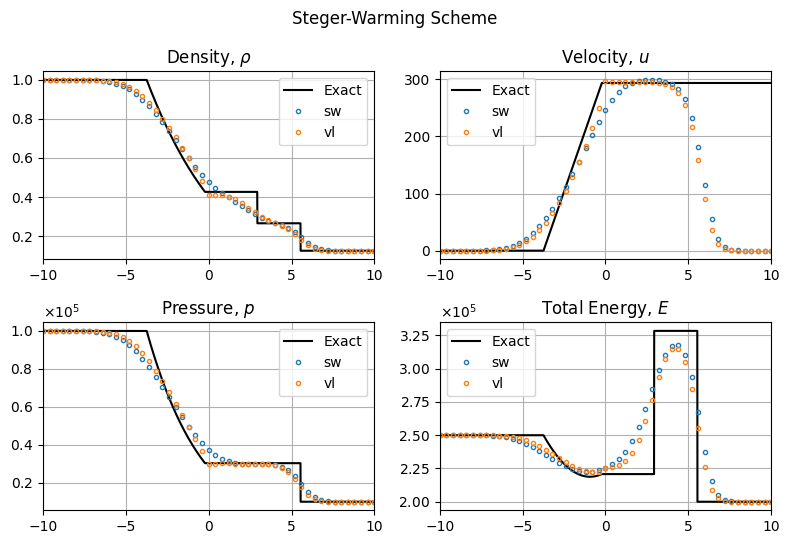

In [186]:
fig, axes = plt.subplots(2, 2, figsize=(8,5.5))
axes = axes.flatten()
columns_to_plot = ["density", "velocity", "pressure", "total_energy"]
titles = [r"Density, $\rho$", r"Velocity, $u$", r"Pressure, $p$", r"Total Energy, $E$"]
for i, var in enumerate(columns_to_plot):
    ax = axes[i]
    ax.plot(exact_df["x"], exact_df[var], label="Exact", color="black")
    for scheme, results_df in results_dict.items():
        if var in results_df.columns:
            ax.plot(results_df["x"], results_df[var], 'o', markersize=3, markerfacecolor=f'None',linewidth=1, label=scheme)
    ax.set_title(titles[i])
    ax.legend()
    ax.grid()
    if exact_df[var].max() > 1e3:
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_xlim(XMIN, XMAX)
fig.suptitle("Steger-Warming Scheme")
fig.tight_layout()
